In [1]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    auc,
    roc_curve,
    precision_recall_curve,
)

print("Библиотеки импортированы.")

Библиотеки импортированы.


In [3]:
current_dir = Path.cwd().resolve()

project_dir = next(
    (
        folder
        for folder in [current_dir, *current_dir.parents]
        if (folder / "data" / "players.csv").is_file()
        and (folder / "notebooks").is_dir()
    ),
    None,
)

if project_dir is None:
    raise FileNotFoundError(
        "Не найден data/players.csv. "
        "Открой в VS Code папку ML players-eda-pw-5 "
        "и проверь название файла."
    )

csv_path = project_dir / "data" / "players.csv"

df = pd.read_csv(csv_path)

print("Папка проекта:", project_dir)
print("Файл данных:", csv_path)
print("Размер данных:", df.shape)

display(df.head())

Папка проекта: /Users/mdnv/Desktop/ML/ML players-eda-pw-5
Файл данных: /Users/mdnv/Desktop/ML/ML players-eda-pw-5/data/players.csv
Размер данных: (19789, 60)


,player_id,common_name,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia Putellas,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,...,60,82,64,15,17,11,15,10,fc27,2026-09-12
1,231747,NaN,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,...,15,34,24,13,5,7,11,6,fc27,2026-09-12
2,239085,NaN,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,...,42,47,33,7,14,13,11,7,fc27,2026-09-12
3,192119,NaN,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,...,20,18,16,87,89,78,90,90,fc27,2026-09-12
4,202126,NaN,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,...,46,44,42,8,10,11,14,11,fc27,2026-09-12


## Постановка задачи

Цель — предсказать, имеет ли игрок рейтинг не ниже 80.

Положительный класс 1: overall_rating ≥ 80.
Отрицательный класс 0: overall_rating < 80.

FP — модель рекомендует игрока с рейтингом ниже 80.
FN — модель пропускает игрока с рейтингом не ниже 80.

Для учебного примера принята цена FP = 1 и FN = 5.
Это допущение, которое необходимо заменить,
если преподаватель задал другое соотношение цен.

Порог выбирается по минимальной стоимости ошибок:
Cost = C_FP × FP + C_FN × FN.

Особенно важна полнота recall, поскольку пропуск
положительного объекта обходится дороже.

In [4]:
y = (df["overall_rating"] >= 80).astype(int)

X = df.select_dtypes(include="number").copy()

X = X.drop(columns=[
    "overall_rating",
    "player_id",
    "height_cm",
    "weight_kg",
])

print("Размер признаков:", X.shape)

print("\nКоличество объектов по классам:")
print(y.value_counts().sort_index())

print(f"\nДоля положительного класса: {y.mean():.2%}")

Размер признаков: (19789, 42)

Количество объектов по классам:
overall_rating
0    18998
1      791
Name: count, dtype: int64

Доля положительного класса: 4.00%


Положительный класс составляет около 4% данных.
Наблюдается выраженный дисбаланс классов.

Модель, всегда предсказывающая класс 0, получила бы
около 96% accuracy, но не обнаружила бы ни одного
положительного объекта. Поэтому дополнительно
оцениваются precision, recall, F1 и PR-кривая.

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nДоли положительного класса:")
print(f"Train: {y_train.mean():.2%}")
print(f"Validation: {y_val.mean():.2%}")
print(f"Test: {y_test.mean():.2%}")

Train: (11873, 42)
Validation: (3958, 42)
Test: (3958, 42)

Доли положительного класса:
Train: 4.00%
Validation: 3.99%
Test: 3.99%


In [6]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42,
    )),
])

model.fit(X_train, y_train)

print("Модель обучена.")

Модель обучена.


In [7]:
positive_class_index = list(
    model.named_steps["classifier"].classes_
).index(1)

val_proba = model.predict_proba(X_val)[:, positive_class_index]
test_proba = model.predict_proba(X_test)[:, positive_class_index]

print("Первые 10 вероятностей:")
print(np.round(test_proba[:10], 4))

print("\nКоличество вероятностей:", len(test_proba))

Первые 10 вероятностей:
[0.     0.     0.     0.     0.0006 0.     0.     0.     0.0006 0.    ]

Количество вероятностей: 3958


In [8]:
print(test_proba[:20])

[7.08174001e-10 2.71056172e-09 4.69247512e-06 4.26771382e-06
 6.32374595e-04 6.38941663e-08 5.63522322e-13 1.99912846e-10
 6.11056193e-04 1.87243162e-13 1.32463680e-11 1.60037118e-09
 6.58386974e-03 2.00342545e-08 6.53289029e-05 2.08769089e-07
 9.32191239e-05 2.07424778e-02 5.96383408e-09 8.77020948e-06]


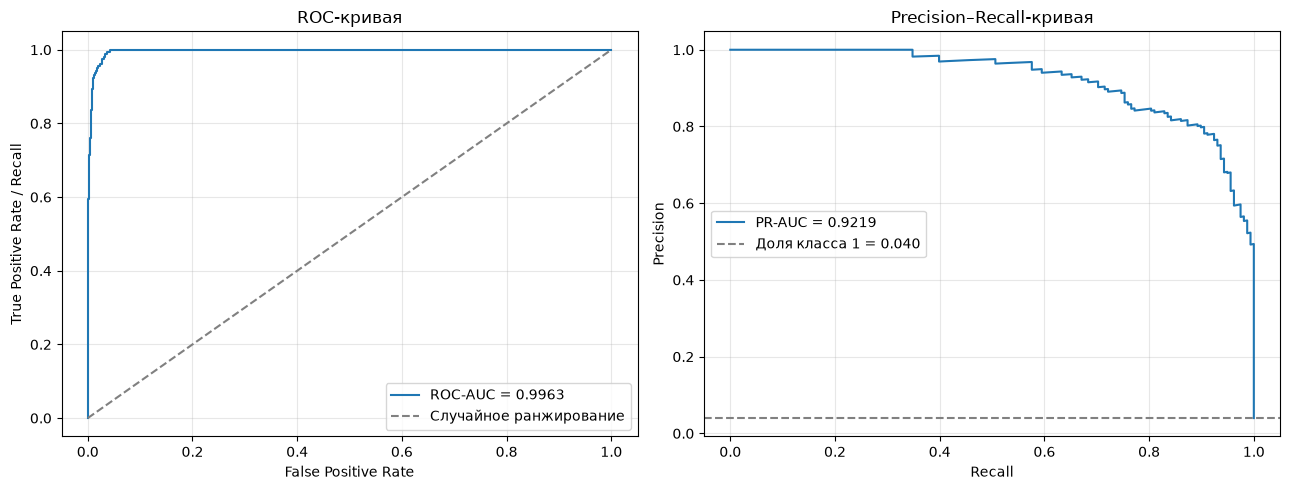

ROC-AUC: 0.9963
PR-AUC, метод трапеций: 0.9219
Average Precision: 0.9222


In [9]:
fpr, tpr, _ = roc_curve(y_test, test_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_proba,
)

roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = auc(recall_curve, precision_curve)
ap = average_precision_score(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Случайное ранжирование",
)
axes[0].set_title("ROC-кривая")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}",
)
axes[1].axhline(
    y_test.mean(),
    linestyle="--",
    color="gray",
    label=f"Доля класса 1 = {y_test.mean():.3f}",
)
axes[1].set_title("Precision–Recall-кривая")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC, метод трапеций: {pr_auc:.4f}")
print(f"Average Precision: {ap:.4f}")

ROC-AUC оценивает качество ранжирования объектов.

Значение около 0,996 означает, что случайный положительный
объект получает более высокую оценку, чем случайный
отрицательный, примерно в 99,6% таких пар.
Это не означает accuracy 99,6%.

Из-за дисбаланса классов дополнительно используется
PR-кривая, отражающая соотношение precision и recall
для положительного класса.

Высокое качество ожидаемо: характеристики игроков
тесно связаны с их общим рейтингом.

In [10]:
# Замени эти значения, если преподаватель выдал другие.
C_FP = 1
C_FN = 5

print("Цена ложноположительной ошибки:", C_FP)
print("Цена ложноотрицательной ошибки:", C_FN)

Цена ложноположительной ошибки: 1
Цена ложноотрицательной ошибки: 5


In [11]:
thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

rows = []

for threshold in thresholds:
    val_pred = (val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        val_pred,
        labels=[0, 1],
    ).ravel()

    rows.append({
        "threshold": threshold,
        "FP": fp,
        "FN": fn,
        "precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, val_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, val_pred, zero_division=0
        ),
        "cost": C_FP * fp + C_FN * fn,
    })

threshold_table = pd.DataFrame(rows)

# Если стоимость совпадает, предпочитаем меньше FN,
# затем меньше FP.
sorted_thresholds = threshold_table.sort_values(
    by=["cost", "FN", "FP", "threshold"]
)

best_row = sorted_thresholds.iloc[0]
best_threshold = float(best_row["threshold"])

print(f"Выбранный порог: {best_threshold:.2f}")

display(sorted_thresholds.head(10).round(4))

Выбранный порог: 0.18


,threshold,FP,FN,precision,recall,F1,cost
17,0.18,57,9,0.7233,0.9430,0.8187,102
16,0.17,60,9,0.7129,0.9430,0.8120,105
18,0.19,56,10,0.7255,0.9367,0.8177,106
15,0.16,63,9,0.7028,0.9430,0.8054,108
12,0.13,74,7,0.6711,0.9557,0.7885,109
13,0.14,69,8,0.6849,0.9494,0.7958,109
24,0.25,45,13,0.7632,0.9177,0.8333,110
19,0.20,56,11,0.7241,0.9304,0.8144,111
23,0.24,46,13,0.7592,0.9177,0.8309,111
11,0.12,77,7,0.6623,0.9557,0.7824,112


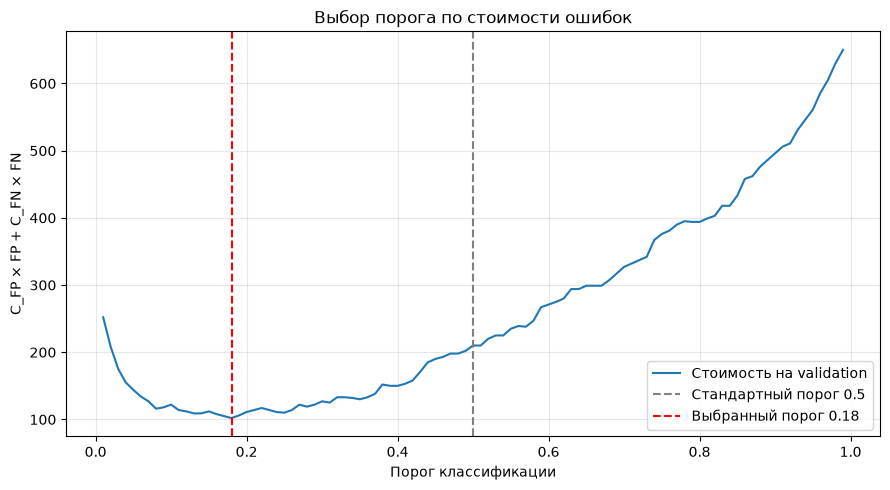

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_table["threshold"],
    threshold_table["cost"],
    label="Стоимость на validation",
)

plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    label="Стандартный порог 0.5",
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Выбранный порог {best_threshold:.2f}",
)

plt.title("Выбор порога по стоимости ошибок")
plt.xlabel("Порог классификации")
plt.ylabel("C_FP × FP + C_FN × FN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def evaluate_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_true, predictions, zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "cost": C_FP * fp + C_FN * fn,
    }


comparison = pd.DataFrame([
    evaluate_threshold(y_test, test_proba, 0.5),
    evaluate_threshold(y_test, test_proba, best_threshold),
])

display(comparison.round(4))

,threshold,accuracy,precision,recall,F1,TN,FP,FN,TP,cost
0,0.50,0.9861,0.8411,0.8038,0.8220,3776,24,31,127,179
1,0.18,0.9813,0.6963,0.9430,0.8011,3735,65,9,149,110


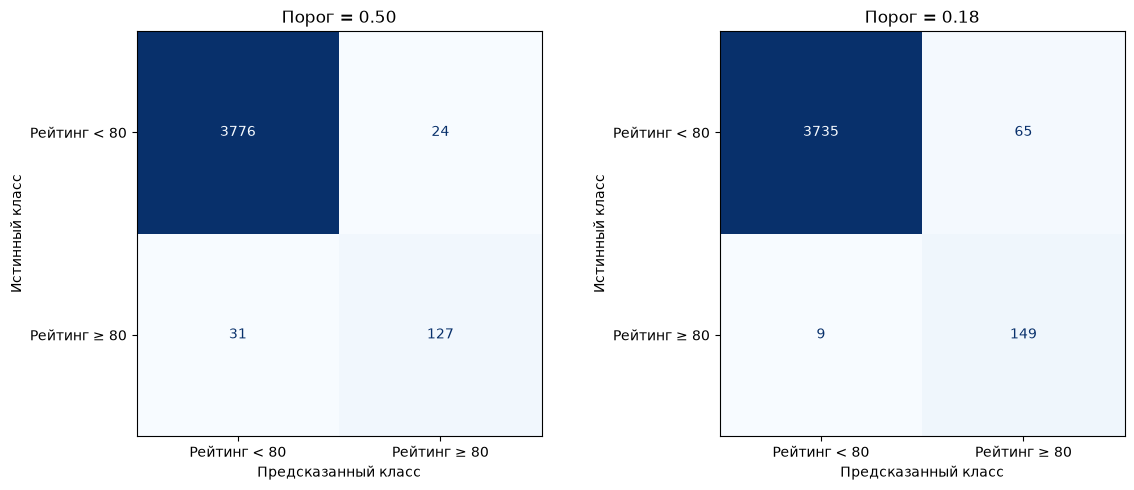

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, threshold in zip(axes, [0.5, best_threshold]):
    predictions = (test_proba >= threshold).astype(int)

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    )

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Рейтинг < 80", "Рейтинг ≥ 80"],
    )

    cm_display.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )

    ax.set_title(f"Порог = {threshold:.2f}")
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()

In [15]:
default_result = comparison.iloc[0]
selected_result = comparison.iloc[1]

print(
    f"Обучена логистическая регрессия для определения игроков "
    f"с рейтингом не ниже 80.\n\n"
    f"ROC-AUC = {roc_auc:.4f}; "
    f"PR-AUC = {pr_auc:.4f}; "
    f"AP = {ap:.4f}.\n\n"
    f"При цене FP = {C_FP} и FN = {C_FN} "
    f"на validation выбран порог {best_threshold:.3f} "
    f"по минимуму стоимости ошибок.\n\n"
    f"На test recall изменился "
    f"с {default_result['recall']:.4f} "
    f"до {selected_result['recall']:.4f}.\n"
    f"FN: {int(default_result['FN'])} → "
    f"{int(selected_result['FN'])}.\n"
    f"FP: {int(default_result['FP'])} → "
    f"{int(selected_result['FP'])}.\n"
    f"Стоимость ошибок: {default_result['cost']:.0f} → "
    f"{selected_result['cost']:.0f}."
)

if selected_result["cost"] < default_result["cost"]:
    print(
        "\nВыбранный порог снизил стоимость ошибок "
        "на независимом test."
    )
elif selected_result["cost"] == default_result["cost"]:
    print(
        "\nНа независимом test стоимость ошибок "
        "оказалась одинаковой."
    )
else:
    print(
        "\nНа независимом test снижение стоимости "
        "не подтвердилось. Порог по test не перенастраивался."
    )

Обучена логистическая регрессия для определения игроков с рейтингом не ниже 80.

ROC-AUC = 0.9963; PR-AUC = 0.9219; AP = 0.9222.

При цене FP = 1 и FN = 5 на validation выбран порог 0.180 по минимуму стоимости ошибок.

На test recall изменился с 0.8038 до 0.9430.
FN: 31 → 9.
FP: 24 → 65.
Стоимость ошибок: 179 → 110.

Выбранный порог снизил стоимость ошибок на независимом test.


Обучена логистическая регрессия для определения игроков с рейтингом не ниже 80.

ROC-AUC = 0.9963; PR-AUC = 0.9219; AP = 0.9222.

При цене FP = 1 и FN = 5 на validation выбран порог 0.180 по минимуму стоимости ошибок.

На test recall изменился с 0.8038 до 0.9430.
FN: 31 → 9.
FP: 24 → 65.
Стоимость ошибок: 179 → 110.

Выбранный порог снизил стоимость ошибок на независимом test.

Порог выбран на validation, а итоговая оценка выполнена
на отдельной тестовой выборке.

Основной критерий выбора — суммарная стоимость FP и FN.
Recall особенно важен, поскольку цена FN выше цены FP.

Из-за дисбаланса классов accuracy не используется
как единственная метрика качества.